# Análisis en batch de defectos — piezas cilíndricas

Este notebook itera sobre todas las muestras de `gears_defectos_xyz_etiquetados`
y aplica el pipeline completo de análisis de defectos (ver `gear_defect_pipeline.py`):

1. Carga XYZ + máscara YOLO (con erosión)
2. Preprocesado (NN fill + mediana)
3. Normales SG 2D → segmentación flat/wall
4. Histograma Z → caras planas (K_flat)
5. Extensión de etiquetas al defecto (líneas/círculos geométricos)
6. Z_nom por griddata desde anillo
7. Multi-splat gaussiano (K=1..K_MAX), selección por BIC
8. Métricas OBB

**Resultado**: tabla con una fila por muestra y todas las métricas.

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, os.path.abspath("."))   # para importar gear_defect_pipeline
sys.path.insert(0, os.path.abspath(".."))  # para camera.raw

from gear_defect_pipeline import (
    analyze_defect,
    gauss_mixture,
    DEFAULT_PARAMS,
)

## Parámetros globales y descubrimiento de muestras

In [2]:
# ── Directorio raíz de las muestras ──────────────────────────────────────────
BASE_DIR = "../gears_defectos_xyz_etiquetados"

# ── Parámetros del pipeline (se pueden sobreescribir por muestra) ─────────────
PIPELINE_PARAMS = dict(
    erosion_px    = 5,
    med_win       = 15,
    sg_win_px     = 21,
    thr_tapa_deg  = 30.0,
    n_wall_bins   = 16,
    ring_mm       = 8.0,
    search_mm     = 10.0,
    k_max         = 12,
    win_defect_mm = 4.0,
    lambda_pen    = 5.0,
    thr_frac      = 0.05,
    n_splat_sub   = 2000,
)

# ── Descubrir todas las muestras disponibles ─────────────────────────────────
def discover_samples(base_dir: str) -> list[str]:
    """Devuelve lista de nombres de muestra que tienen save_xyz y rgb_seg."""
    samples = []
    for name in sorted(os.listdir(base_dir)):
        entities = os.path.join(base_dir, name, "debug", "entities")
        xyz_ok  = os.path.isfile(os.path.join(entities, "save_xyz", f"{name}_save_xyz.raw"))
        seg_ok  = os.path.isfile(os.path.join(entities, "rgb_seg",  f"{name}_rgb_seg.txt"))
        if xyz_ok and seg_ok:
            samples.append(name)
    return samples

SAMPLES = discover_samples(BASE_DIR)
print(f"Muestras encontradas: {len(SAMPLES)}")
for s in SAMPLES:
    print(f"  {s}")

Muestras encontradas: 5
  061125_144524_P17231_S4_7762
  061125_144533_P17234_S3_7762
  151225_155112_P44473_S2_7761
  151225_160136_P44512_S2_7761
  311025_113230_P11447_S7_7762


## Análisis en batch

In [3]:
results_all = {}   # sample -> lista de dicts, uno por defecto
errors      = {}   # sample -> excepción si falló

for i, sample in enumerate(SAMPLES):
    print(f"\n[{i+1}/{len(SAMPLES)}] {sample}")
    try:
        defs = analyze_defect(sample, BASE_DIR, verbose=True, **PIPELINE_PARAMS)
        results_all[sample] = defs
        for d in defs:
            idx = d['defect_idx']
            print(f"  ✓  defecto {idx}  "
                  f"largo={d['largo']:.2f}mm  ancho={d['ancho']:.2f}mm  "
                  f"V+={d['V_pos']:.3f}  V-={d['V_neg']:.3f}  std={d['Z_diff_std']:.3f}mm")
    except Exception as exc:
        errors[sample] = exc
        print(f"  ✗  ERROR: {exc}")

print(f"\nCompletadas: {len(results_all)}/{len(SAMPLES)}  |  Errores: {len(errors)}")



[1/5] 061125_144524_P17231_S4_7762

── Defecto 1/1 ──
[061125_144524_P17231_S4_7762[0]] Multi-splat POSITIVO …
  K=1: V=0.2946 mm³  nfev=26  t=8ms
  K=2: V=0.3589 mm³  nfev=16  t=15ms
  K=3: V=0.2976 mm³  nfev=33  t=34ms
  K=4: V=0.3224 mm³  nfev=16  t=45ms
  K=5: V=0.3387 mm³  nfev=29  t=77ms
  K=6: V=0.3581 mm³  nfev=15  t=94ms
  K=7: V=0.4532 mm³  nfev=42  t=209ms
  K=8: V=0.5582 mm³  nfev=14  t=230ms
  K=9: V=0.6632 mm³  nfev=14  t=253ms
  K=10: V=0.7682 mm³  nfev=13  t=278ms
  K=11: V=0.8733 mm³  nfev=11  t=304ms
  K=12: V=0.4452 mm³  nfev=33  t=500ms
[061125_144524_P17231_S4_7762[0]] Multi-splat NEGATIVO …
  K=1: V=11.0802 mm³  nfev=15  t=6ms
  K=2: V=13.1516 mm³  nfev=21  t=18ms
  K=3: V=17.6473 mm³  nfev=16  t=25ms
  K=4: V=15.4286 mm³  nfev=16  t=35ms
  K=5: V=22.9004 mm³  nfev=20  t=67ms
  K=6: V=23.6041 mm³  nfev=16  t=109ms
  K=7: V=21.2681 mm³  nfev=49  t=298ms
  K=8: V=20.4811 mm³  nfev=18  t=376ms
  K=9: V=21.6036 mm³  nfev=15  t=468ms
  K=10: V=20.7046 mm³  nfev=16  t=

## Tabla de métricas

In [4]:
METRIC_COLS = [
    'sample', 'defect_idx', 'pix_mm', 'K_flat', 'n_defect_px',
    'Z_diff_std', 'Z_diff_min', 'Z_diff_max',
    'K_best_pos', 'V_pos', 'K_best_neg', 'V_neg', 'V_net',
    'largo', 'ancho', 'ang_deg', 'h_max', 'h_min',
    't_total',
]

rows = []
for sample, defs in results_all.items():
    for d in defs:
        rows.append({col: d.get(col) for col in METRIC_COLS})

df = pd.DataFrame(rows).set_index(['sample', 'defect_idx'])

float_cols = ['pix_mm', 'Z_diff_std', 'Z_diff_min', 'Z_diff_max',
               'V_pos', 'V_neg', 'V_net', 'largo', 'ancho', 'ang_deg', 'h_max', 'h_min']
df_display = df.copy()
df_display[float_cols] = df_display[float_cols].round(4)

display(df_display)

out_csv = os.path.join(".", "batch_results.csv")
df.to_csv(out_csv, float_format='%.5f')
print(f"Guardado en {out_csv}")


pix_mm  K_flat  n_defect_px  \
sample                       defect_idx                                
061125_144524_P17231_S4_7762 0           0.1095       3         4347   
061125_144533_P17234_S3_7762 0           0.1069       2         5802   
                             1           0.1069       2          840   
151225_155112_P44473_S2_7761 0           0.1252       3         3699   
151225_160136_P44512_S2_7761 0           0.1269       5         3987   
311025_113230_P11447_S7_7762 0           0.1046       4         9074   
                             1           0.1046       4         2231   
                             2           0.1046       4         2659   

                                         Z_diff_std  Z_diff_min  Z_diff_max  \
sample                       defect_idx                                       
061125_144524_P17231_S4_7762 0               0.2179     -0.8044      0.2104   
061125_144533_P17234_S3_7762 0               0.3077     -0.6680      1.0781   
                             1               0.0773     -0.5462      0.1993   
151225_155112_P44473_S2_7761 0               0.1300     -0.5371      0.2212   
151225_160136_P44512_S2_7761 0               0.2516     -0.4504      0.6024   
311025_113230_P11447_S7_7762 0               0.4925     -1.9676      0.9131   
                             1               0.2871     -1.0838      0.3398   
                             2               0.2703     -1.1455      1.0011   

                                         K_best_pos    V_pos  K_best_neg  \
sample                       defect_idx                                    
061125_144524_P17231_S4_7762 0                    7   0.4532          10   
061125_144533_P17234_S3_7762 0                   10  22.9122           1   
                             1                    8   0.5161           7   
151225_155112_P44473_S2_7761 0                    1   0.0357           7   
151225_160136_P44512_S2_7761 0                    8  10.6602          12   
311025_113230_P11447_S7_7762 0                    9  10.0145          12   
                             1                   10   0.9197          12   
                             2                    8   0.8483          12   

                                            V_neg     V_net    largo    ancho  \
sample                       defect_idx                                         
061125_144524_P17231_S4_7762 0            20.7046  -20.2514  16.7190   9.6145   
061125_144533_P17234_S3_7762 0             1.1716   21.7406  11.2424   9.1450   
                             1             0.7771   -0.2610   5.8030   3.1570   
151225_155112_P44473_S2_7761 0            24.2161  -24.1804  35.2051   2.4336   
151225_160136_P44512_S2_7761 0             4.6430    6.0173  10.4755   8.7215   
311025_113230_P11447_S7_7762 0           163.9063 -153.8917  35.2036  24.2802   
                             1             8.7143   -7.7945  12.7893   3.1432   
                             2             8.8648   -8.0165  11.4513   3.4966   

                                          ang_deg   h_max   h_min    t_total  
sample                       defect_idx                                       
061125_144524_P17231_S4_7762 0           156.8563  0.0240  0.6986   2.011646  
061125_144533_P17234_S3_7762 0           159.5839  0.9106  0.2953  10.881075  
                             1           179.4063  0.0362  0.1755   1.894964  
151225_155112_P44473_S2_7761 0           179.8975  0.0046  0.4660   2.511165  
151225_160136_P44512_S2_7761 0           102.0946  0.5936  0.4536  19.267140  
311025_113230_P11447_S7_7762 0           116.0068  0.3664  1.8274   9.601552  
                             1           178.7662  0.2682  0.9030   2.701857  
                             2           174.1428  0.9460  0.8585   2.580426

Guardado en ./batch_results.csv


## Visualización comparativa

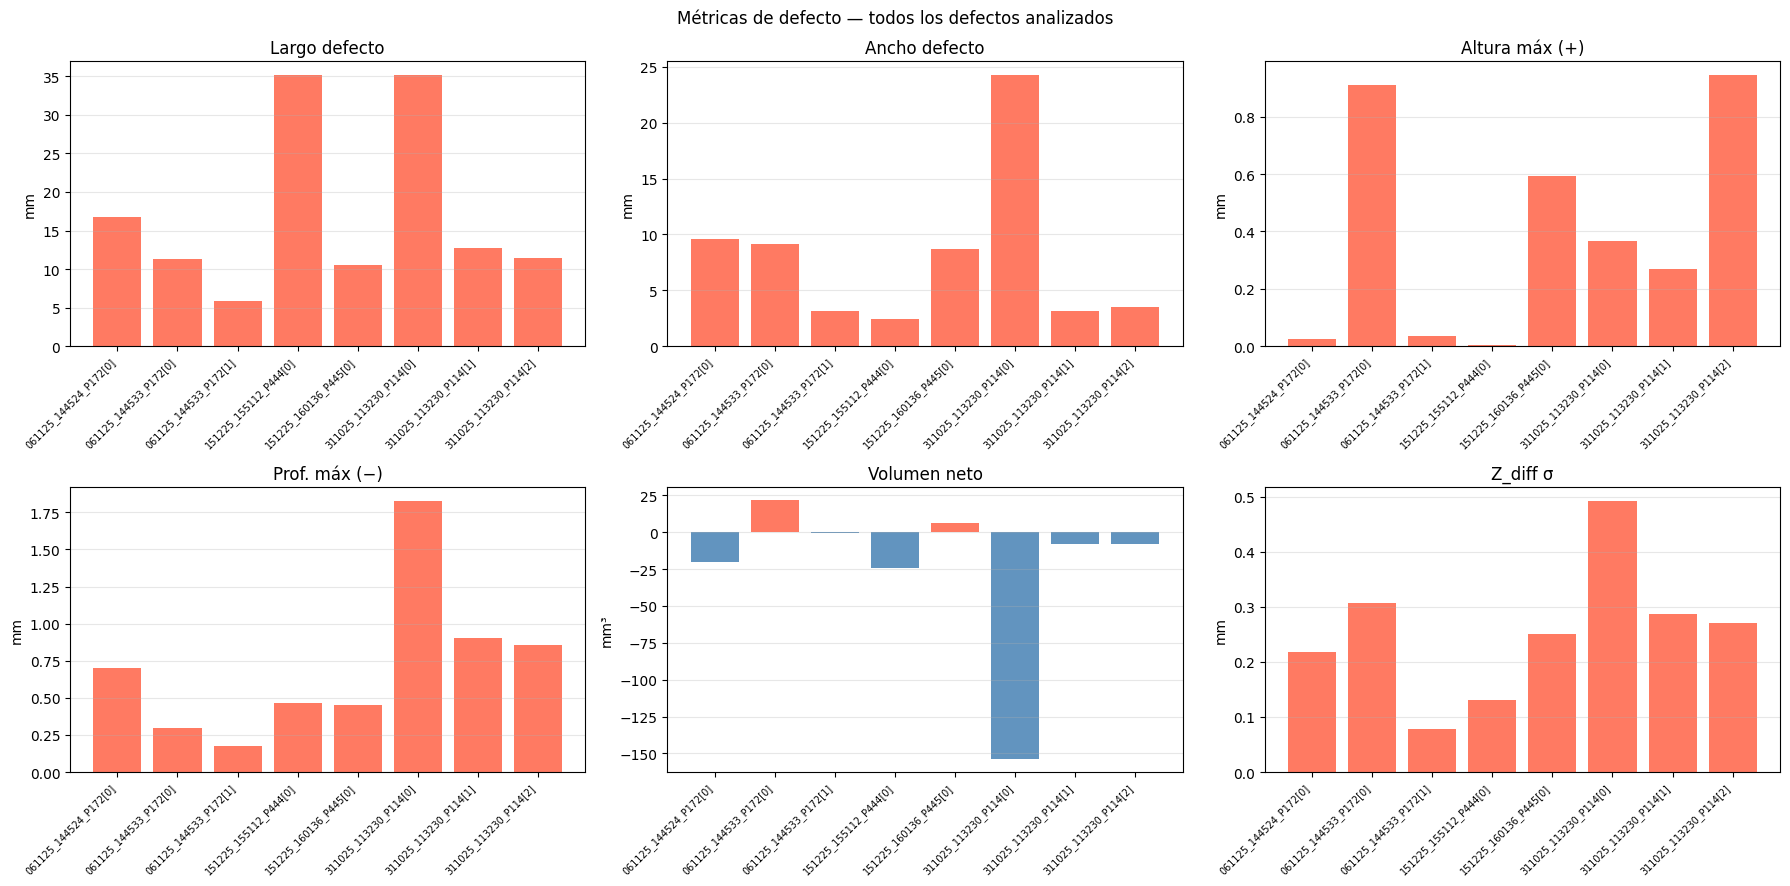

In [5]:
if len(df) == 0:
    print("Sin resultados para visualizar.")
else:
    df_flat = df.reset_index()
    df_flat['label'] = df_flat.apply(
        lambda r: f"{r['sample'][:18]}[{r['defect_idx']}]", axis=1)
    labels_short = df_flat['label'].tolist()
    x = np.arange(len(labels_short))

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))

    def bar(ax, col, title, unit=''):
        vals = df_flat[col].values.astype(float)
        colors = ['tomato' if v > 0 else 'steelblue' for v in vals]
        ax.bar(x, vals, color=colors, alpha=0.85)
        ax.set_xticks(x); ax.set_xticklabels(labels_short, rotation=45, ha='right', fontsize=7)
        ax.set_title(title); ax.set_ylabel(unit); ax.grid(axis='y', alpha=0.3)

    bar(axes[0, 0], 'largo',     'Largo defecto',  'mm')
    bar(axes[0, 1], 'ancho',     'Ancho defecto',  'mm')
    bar(axes[0, 2], 'h_max',     'Altura máx (+)', 'mm')
    bar(axes[1, 0], 'h_min',     'Prof. máx (−)',  'mm')
    bar(axes[1, 1], 'V_net',     'Volumen neto',   'mm³')
    bar(axes[1, 2], 'Z_diff_std','Z_diff σ',       'mm')

    plt.suptitle('Métricas de defecto — todos los defectos analizados', fontsize=12)
    plt.tight_layout()
    plt.show()


## Galería: Z_diff + OBB para todas las muestras analizadas

Para cada muestra se muestra: imagen Z completa de la pieza | Z_diff + splats + OBB.


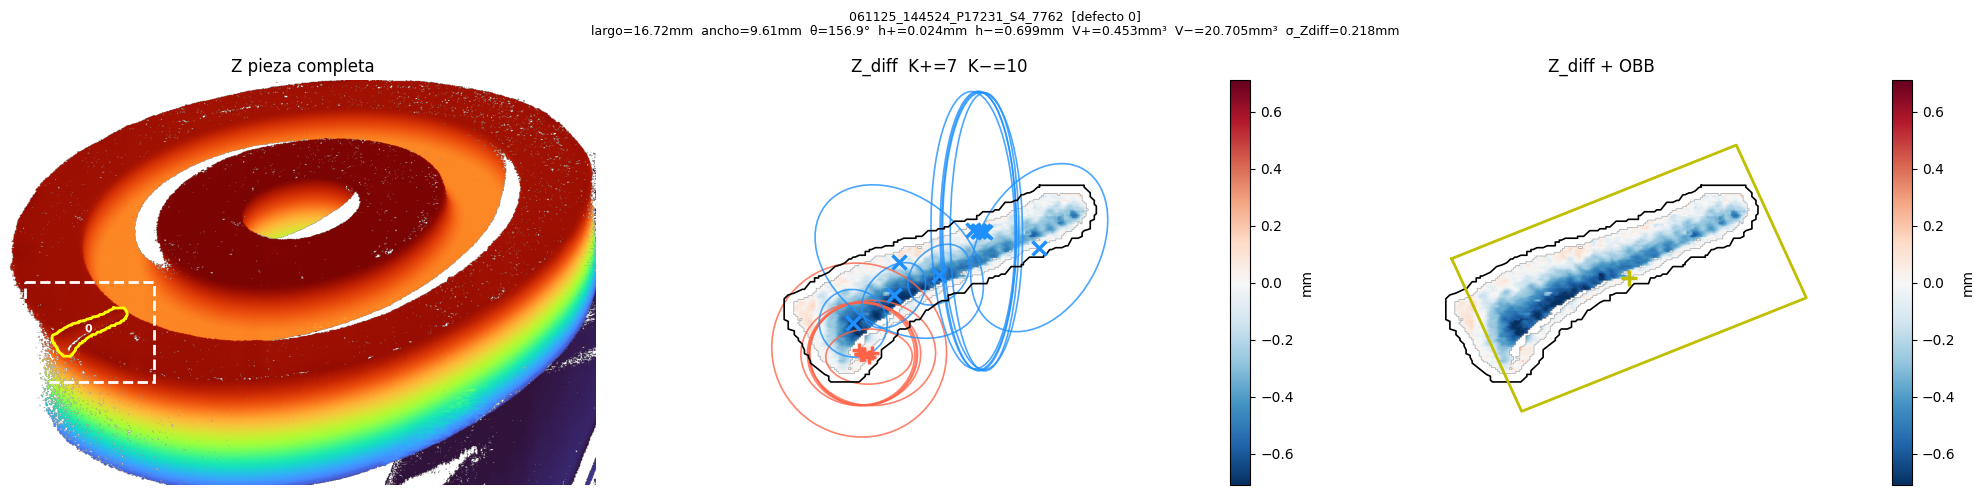

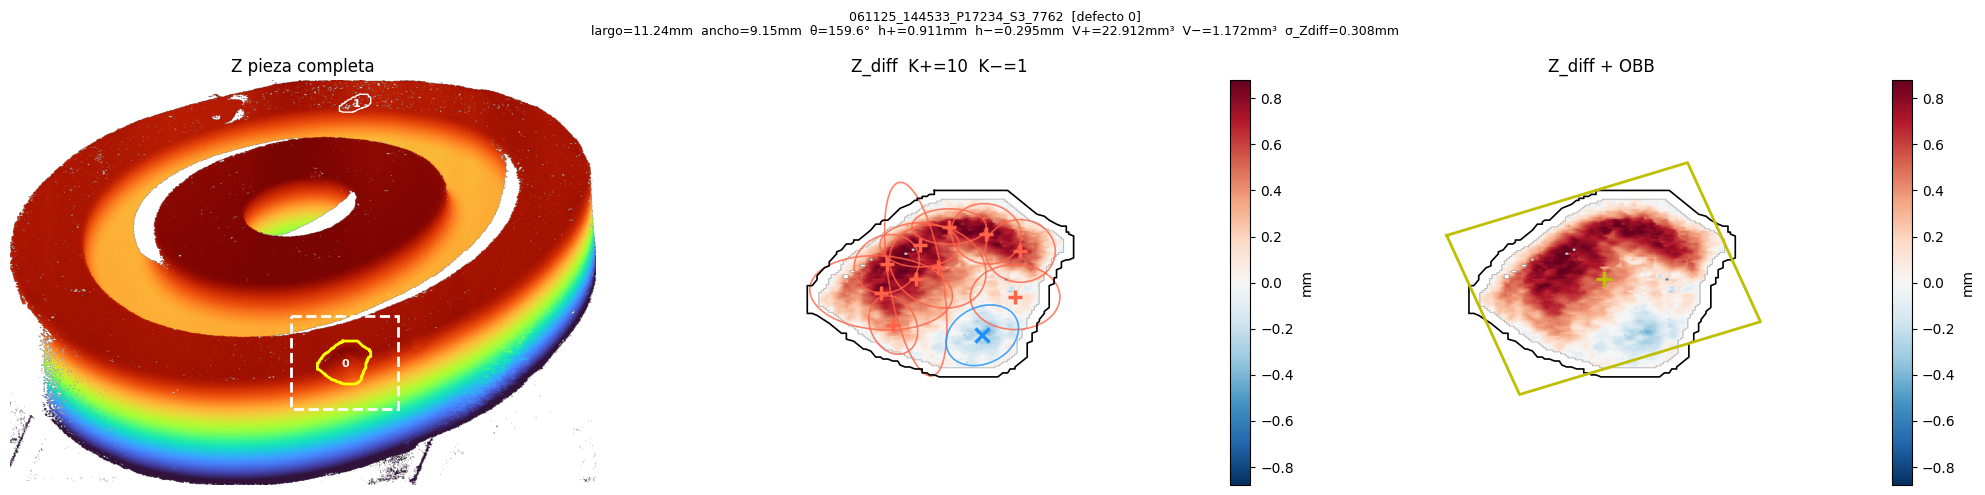

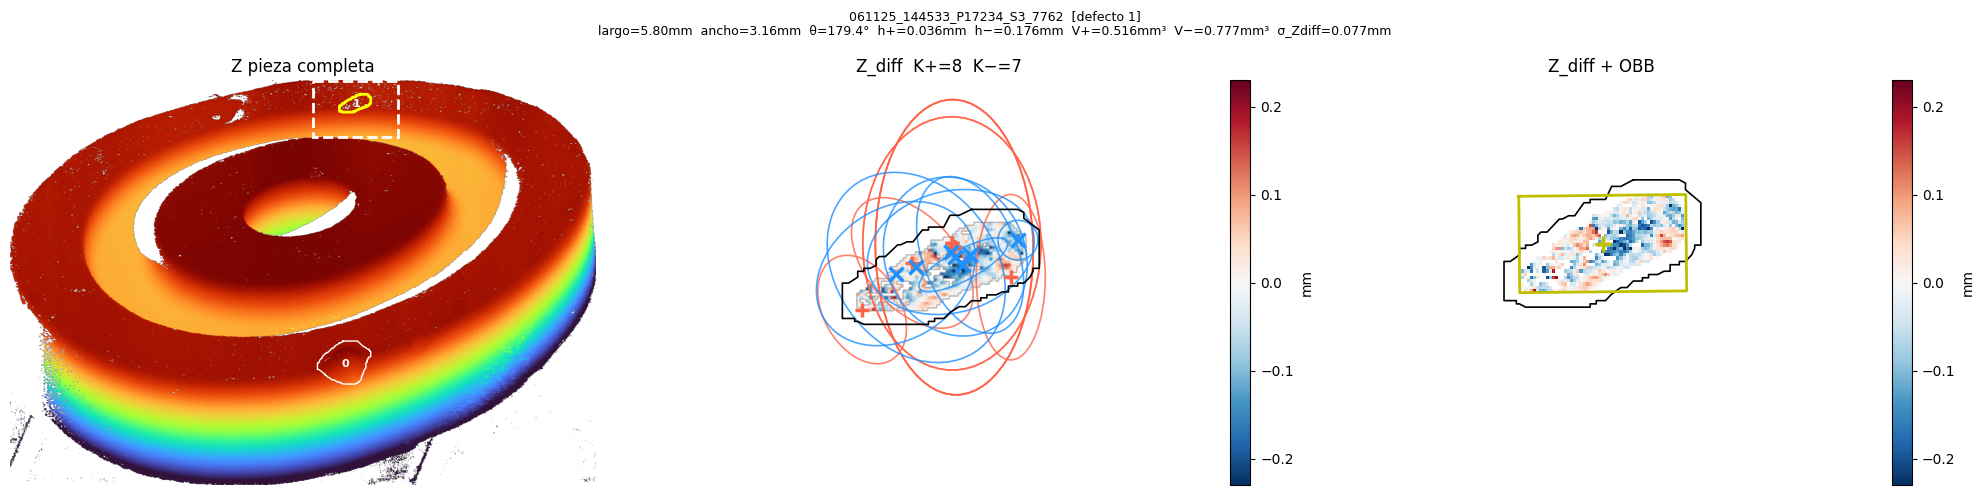

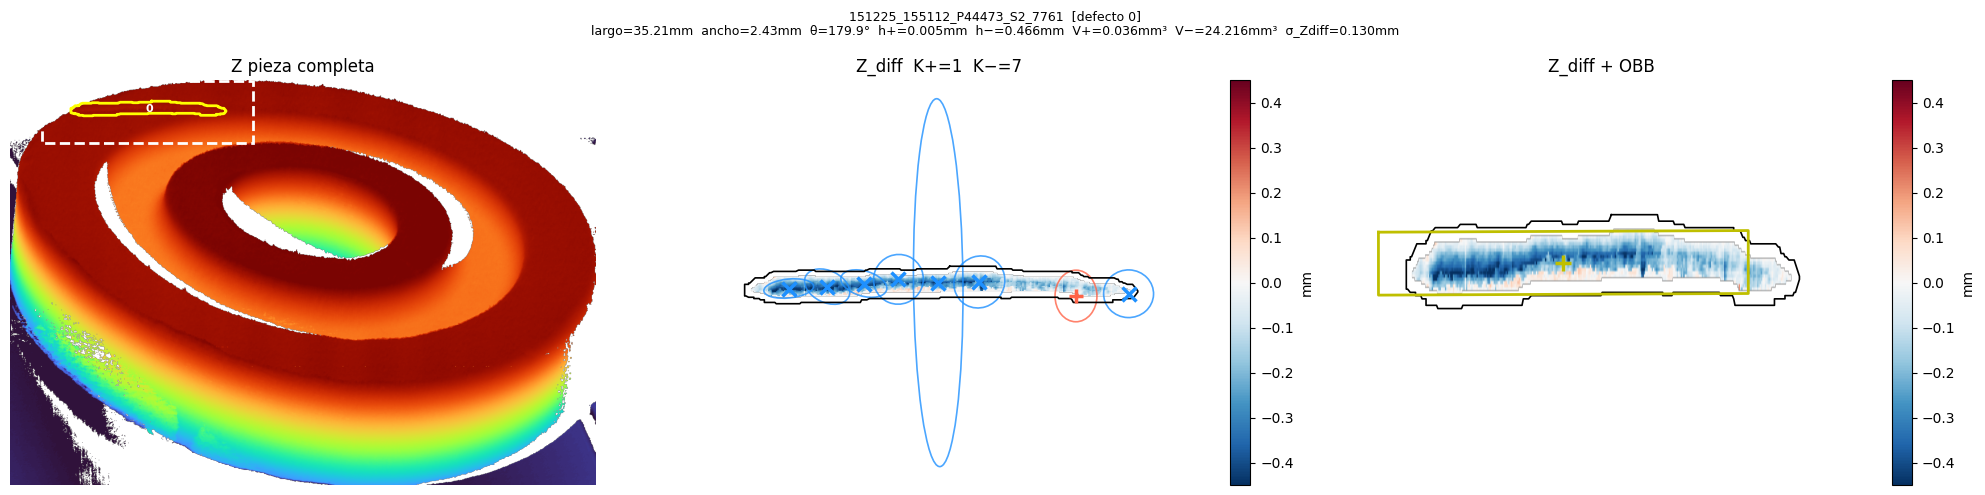

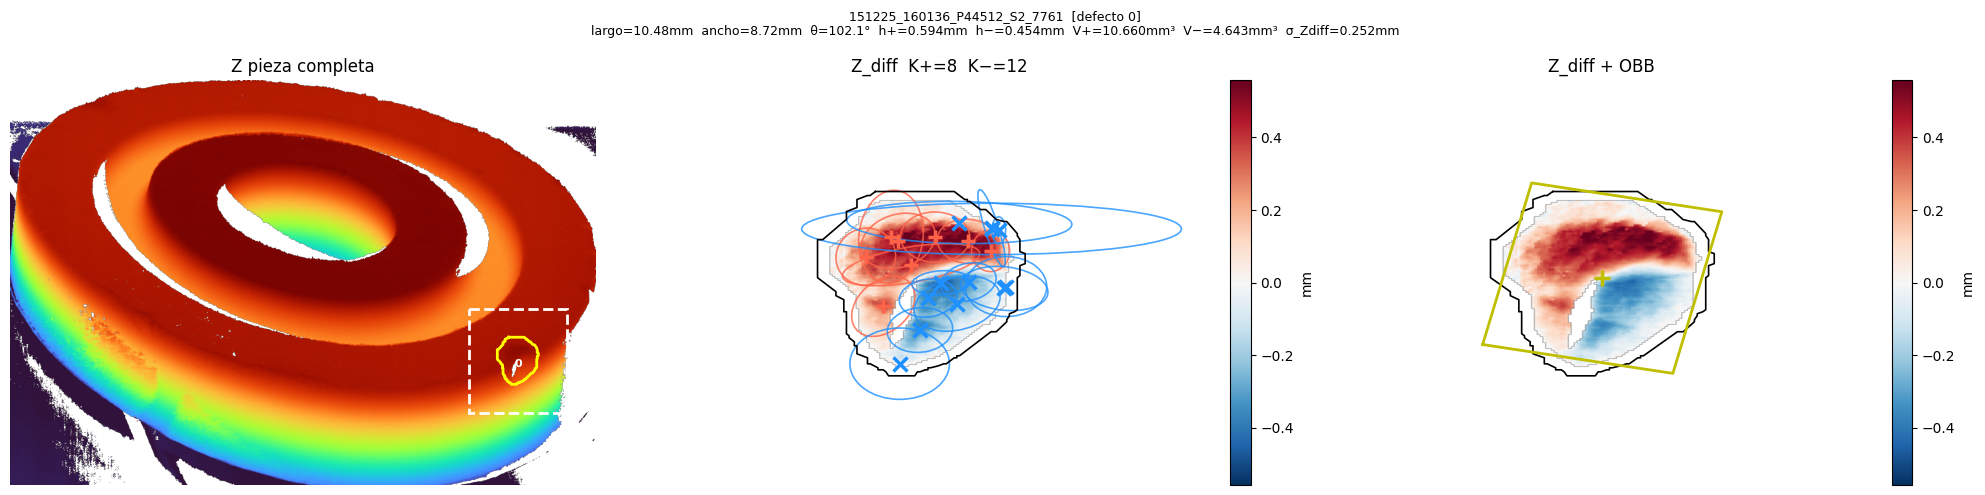

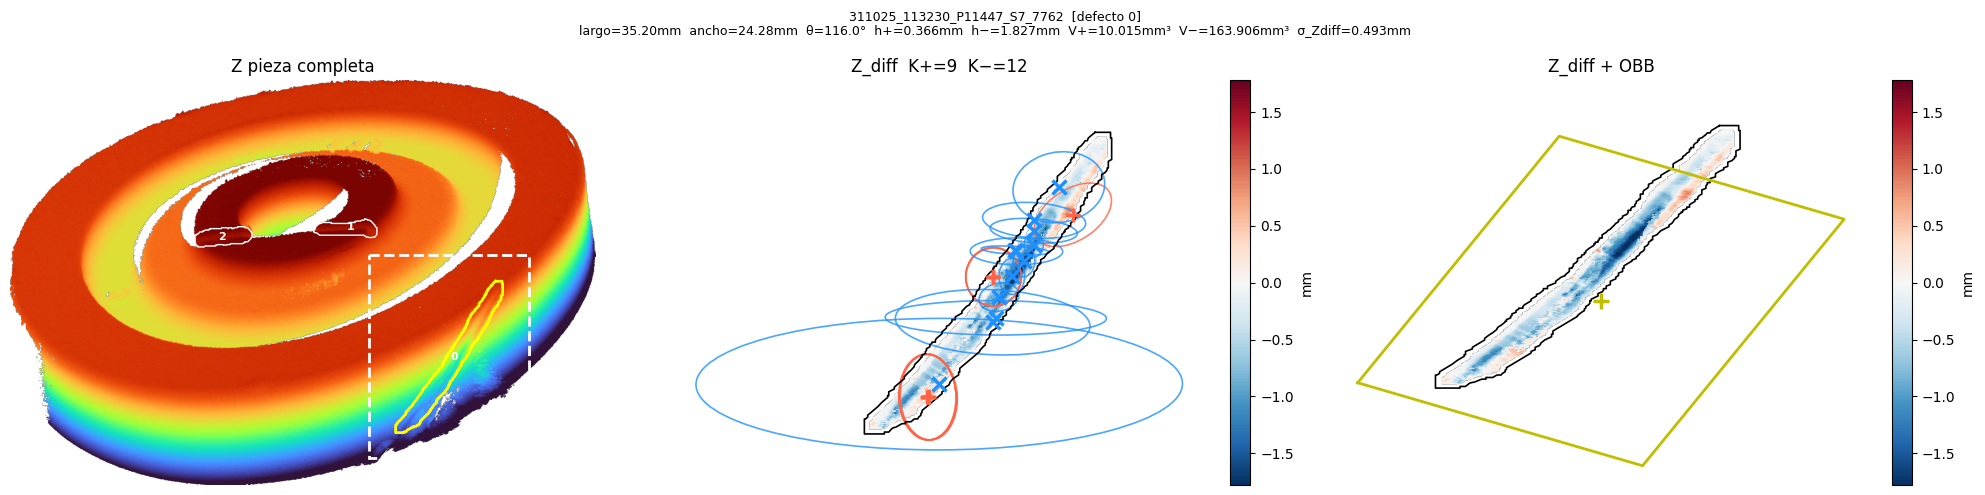

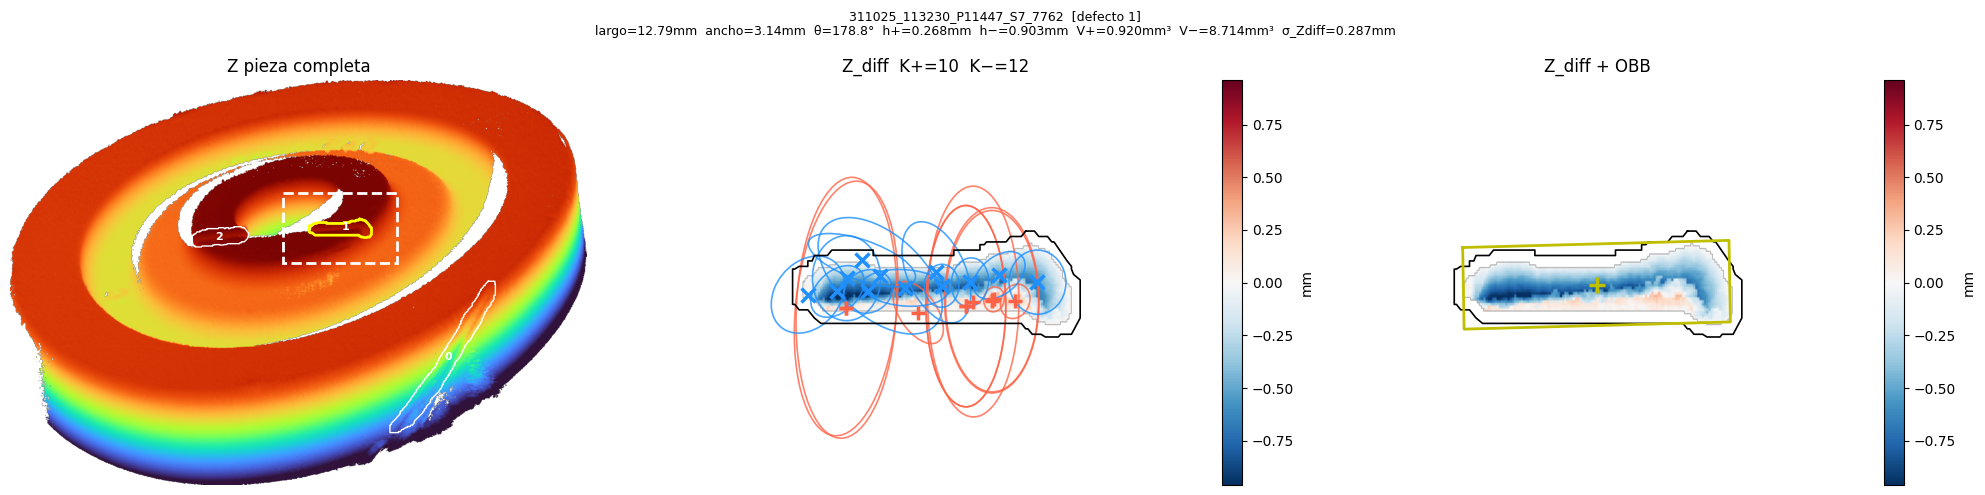

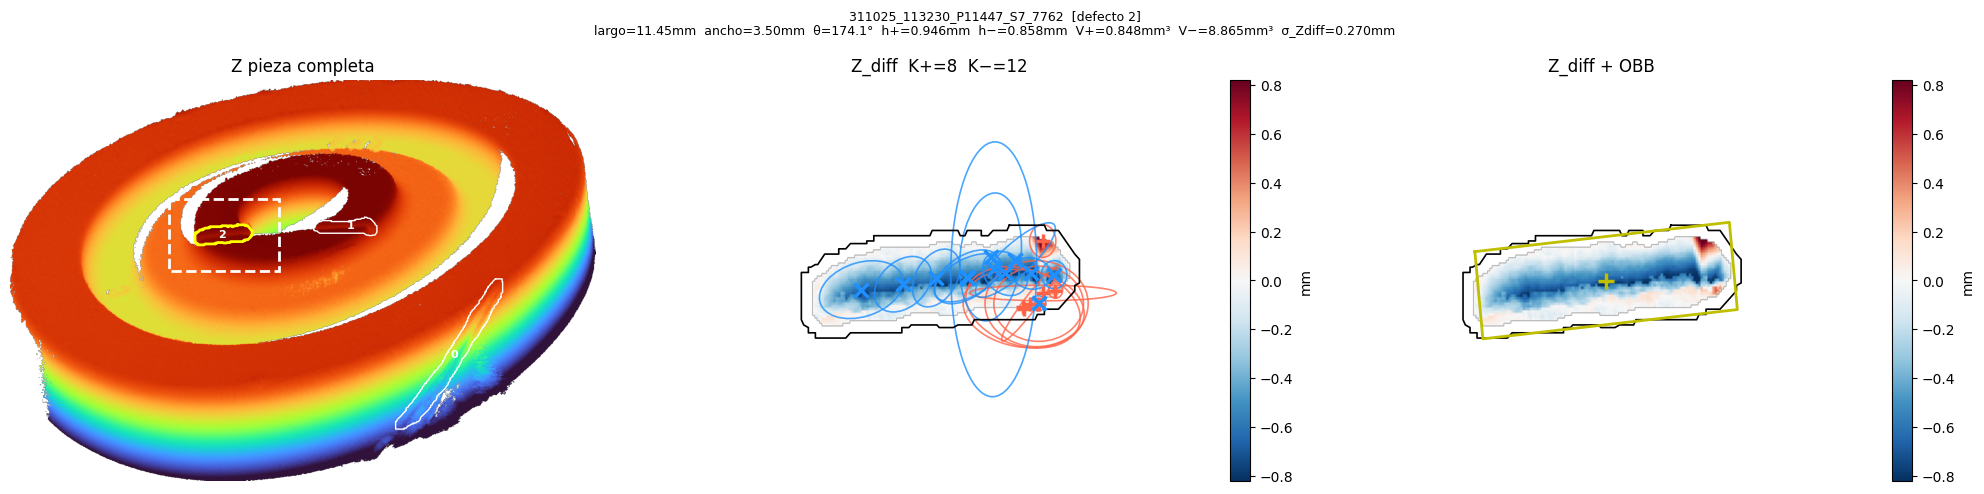

In [6]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import camera.raw as raw
from gear_defect_pipeline import load_xyz

# Cachés de Z_full para no recargar la misma muestra varias veces
_z_full_cache = {}

def get_z_full(sample):
    if sample in _z_full_cache:
        return _z_full_cache[sample]
    entities = os.path.join(BASE_DIR, sample, "debug", "entities")
    xyz_path = os.path.join(entities, "save_xyz", f"{sample}_save_xyz.raw")
    xyz_full = raw.read_img_raw(xyz_path)
    Z_full = xyz_full[:, :, 2].astype(float)
    Z_full[~(np.isfinite(Z_full) & (Z_full != 0))] = np.nan
    _z_full_cache[sample] = Z_full
    return Z_full


for sample, defs in results_all.items():
    Z_full = get_z_full(sample)
    vmin_z = float(np.nanpercentile(Z_full, 2))
    vmax_z = float(np.nanpercentile(Z_full, 98))

    # Todos los polígonos de esta muestra (para superponerlos en el panel global)
    all_polys = [d['polygon'] for d in defs]

    for res in defs:
        idx   = res['defect_idx']
        pix   = res['pix_mm']
        Zd    = res['Z_diff']
        p_pos = res['params_pos']
        p_neg = res['params_neg']
        obb   = res['obb']
        poly  = res['polygon']          # polígono de ESTE defecto
        rows_d = res['rows_def_s']
        cols_d = res['cols_def_s']

        # Recorte alrededor de este defecto
        margin = 60
        r0v = max(0, rows_d.min() - margin);  r1v = min(Zd.shape[0], rows_d.max() + margin)
        c0v = max(0, cols_d.min() - margin);  c1v = min(Zd.shape[1], cols_d.max() + margin)
        Zd_cr = Zd[r0v:r1v, c0v:c1v]

        finite_vals = Zd[np.isfinite(Zd)]
        vmax_d = float(np.nanpercentile(np.abs(finite_vals), 99)) if len(finite_vals) else 1.0

        fig, axes = plt.subplots(1, 3, figsize=(20, 5))

        # ── Panel 1: Z pieza completa con recuadros ───────────────────────────
        axes[0].imshow(Z_full, cmap='turbo', aspect='auto', vmin=vmin_z, vmax=vmax_z)
        # Recuadro del defecto actual (blanco sólido)
        from matplotlib.patches import Rectangle
        rect = Rectangle((c0v, r0v), c1v - c0v, r1v - r0v,
                         linewidth=2, edgecolor='white', facecolor='none', linestyle='--')
        axes[0].add_patch(rect)
        # Todos los polígonos de la muestra superpuestos
        for j, pts in enumerate(all_polys):
            closed = np.vstack([pts, pts[0]])
            color = 'yellow' if j == idx else 'white'
            lw    = 2.0      if j == idx else 1.0
            axes[0].plot(closed[:, 0], closed[:, 1], '-', color=color, lw=lw)
            cy_label = pts[:, 1].mean();  cx_label = pts[:, 0].mean()
            axes[0].text(cx_label, cy_label, str(j), color='white', fontsize=8,
                         ha='center', va='center', fontweight='bold')
        axes[0].set_title('Z pieza completa')
        axes[0].axis('off')

        # ── Panel 2: Z_diff + splats ──────────────────────────────────────────
        im1 = axes[1].imshow(Zd_cr, cmap='RdBu_r', aspect='auto', vmin=-vmax_d, vmax=vmax_d)
        plt.colorbar(im1, ax=axes[1], label='mm', fraction=0.046, pad=0.04)
        closed_l = np.vstack([poly, poly[0]]) - np.array([c0v, r0v])
        axes[1].plot(closed_l[:, 0], closed_l[:, 1], 'k-', lw=1.2)
        for j in range(len(p_pos) // 6):
            cx = p_pos[6*j+1]/pix - c0v;  cy = p_pos[6*j+2]/pix - r0v
            sx = p_pos[6*j+3]/pix;        sy = p_pos[6*j+4]/pix
            axes[1].plot(cx, cy, '+', color='tomato', ms=10, mew=2.5)
            axes[1].add_patch(mpatches.Ellipse((cx, cy), 4*sx, 4*sy,
                angle=np.degrees(p_pos[6*j+5]), fill=False, edgecolor='tomato', lw=1.2, alpha=0.8))
        for j in range(len(p_neg) // 6):
            cx = p_neg[6*j+1]/pix - c0v;  cy = p_neg[6*j+2]/pix - r0v
            sx = p_neg[6*j+3]/pix;        sy = p_neg[6*j+4]/pix
            axes[1].plot(cx, cy, 'x', color='dodgerblue', ms=10, mew=2.5)
            axes[1].add_patch(mpatches.Ellipse((cx, cy), 4*sx, 4*sy,
                angle=np.degrees(p_neg[6*j+5]), fill=False, edgecolor='dodgerblue', lw=1.2, alpha=0.8))
        axes[1].set_title(f'Z_diff  K+={res["K_best_pos"]}  K−={res["K_best_neg"]}')
        axes[1].axis('off')

        # ── Panel 3: Z_diff + OBB ─────────────────────────────────────────────
        im2 = axes[2].imshow(Zd_cr, cmap='RdBu_r', aspect='auto', vmin=-vmax_d, vmax=vmax_d)
        plt.colorbar(im2, ax=axes[2], label='mm', fraction=0.046, pad=0.04)
        axes[2].plot(closed_l[:, 0], closed_l[:, 1], 'k-', lw=1.2)
        mu = obb['mu'];   ev = obb['eig_vecs']
        sl = obb['semieje_largo'];  sw = obb['semieje_ancho']
        corners_mm = mu + np.array([[ sl, sw], [-sl, sw], [-sl,-sw], [ sl,-sw]]) @ ev.T
        corners_px = corners_mm / pix - np.array([c0v, r0v])
        corners_cl = np.vstack([corners_px, corners_px[0]])
        axes[2].plot(corners_cl[:, 0], corners_cl[:, 1], 'y-', lw=2)
        axes[2].plot(mu[0]/pix - c0v, mu[1]/pix - r0v, 'y+', ms=12, mew=2.5)
        axes[2].set_title('Z_diff + OBB')
        axes[2].axis('off')

        plt.suptitle(
            f"{sample}  [defecto {idx}]\n"
            f"largo={res['largo']:.2f}mm  ancho={res['ancho']:.2f}mm  θ={res['ang_deg']:.1f}°  "
            f"h+={res['h_max']:.3f}mm  h−={res['h_min']:.3f}mm  "
            f"V+={res['V_pos']:.3f}mm³  V−={res['V_neg']:.3f}mm³  "
            f"σ_Zdiff={res['Z_diff_std']:.3f}mm",
            fontsize=9)
        plt.tight_layout()
        plt.show()
